# Xora: smarter delivery planning for Waypoint Group

Waypoint Group delivers for three retail brands from two depots. Every evening a dispatcher drafts the next day's routes, and too often the plan is wrong: trucks reach stores after their windows close, festival weeks catch the fleet short, and on a bad day there are more orders than trucks. This notebook is our full answer, from the raw files to the decisions people make with it.

### Results at a glance

| Question | Waypoint today | Our approach | Result on data the models never saw |
|---|---|---|---|
| **Task 1.** How long will each delivery take? | published allowance table, off by 7.1 min a stop | LightGBM on cutoff-time features | **3.9 min** error a stop, **45% less** |
| **Task 1.** Will the truck arrive after the window closes? | slack on paper (log loss 0.287, AUC 0.86) | 1,000 replays of every route, blended with a direct classifier | **log loss 0.136, AUC 0.97**, calibrated |
| **Task 2A.** How much volume in the next 10 weeks? | same week last year | daily festival-aware models added up into ISO weeks | **5.2% error** on total, **3.6%** on chilled; **41 to 54% less error** than last year's pattern |
| **Task 2B.** Who gets served on a peak day? | dispatcher judgement | optimiser with a fixed, agreed order of priorities | **76 of 85 orders**, every repeat deferral served, chilled volume **within 0.2% of the proven maximum**, passes Waypoint's checker |
| **People.** What should each person do? | probabilities nobody reads | traffic lights, clock times and one-line reasons | the red stops are **21% of stops** but carry **over 80%** of expected late arrivals |

Part 11 recomputes every number in this table from the saved models and outputs.

### How this notebook is organised

It follows CRISP-DM, the standard industry process for data science projects. Every part starts with its purpose and ends with a short summary, so it can be read top to bottom or one part at a time.

| CRISP-DM phase | Part |
|---|---|
| Business understanding | 1. The problem and the solution at a glance |
| Data understanding | 2. Data understanding |
| Data preparation | 3. Data quality and cleaning; 4. Label construction; 5. Feature engineering |
| Modelling and evaluation | 6. Task 1: service time and late risk; 7. Task 2A: demand forecast; 8. Task 2B: peak-day allocation |
| Deployment | 9. The decision layer; 10. Deployment, impact and limits; 11. Reload the saved models and run inference |

**To run it:** follow the README to install the pinned requirements and unzip the data into `data/raw/`, then run all cells. A full run rebuilds every table, model and submission from the raw files and takes about an hour on a laptop, most of it in the Task 1 models and the Task 2B optimiser. Seeds are fixed, so results reproduce. The one exception is the last kilometre step of the Task 2B optimiser, which stops on a time limit and so can settle on a slightly different but equally valid route plan on a slower or faster machine.

In [1]:
import json
import subprocess
import sys
import warnings

import joblib
import lightgbm as lgb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import brier_score_loss, log_loss, roc_auc_score

from xora import allocation as al
from xora import checks as ck
from xora import decisions as dl
from xora import features as fe
from xora import forecast as fc
from xora.io import load_processed, load_raw, save_processed
from xora.paths import DATA_RAW, MODELS, REPO_ROOT, REPORTS, SUBMISSIONS, raw_file
from xora.plotting import apply_style, SERIES, INK, INK_SOFT
from xora.simulation import LGB_PARAMS, SEED, TRAVEL_FEATURES, DELAY_FEATURES, RouteSimulator, _fit_lgb
from xora.timeutils import hhmm_to_minutes

warnings.filterwarnings("ignore", category=UserWarning)
apply_style()
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 160)
pd.set_option("display.max_colwidth", 110)

## Part 1. The problem and the solution at a glance

**The business.** Waypoint Group runs 60 vehicles from a distribution centre in Peliyagoda and a regional hub in Kandy, serving 120 outlets for three brands:
- **Fresh**, 80 supermarkets that must be stocked before they open at 8 AM, with chilled goods that only refrigerated trucks (reefers) can carry
- **Style**, 25 fashion stores, many in malls with fixed delivery windows
- **Tech**, 15 electronics stores with heavy, fragile, high-value orders

**Three questions, three decisions.**

| Task | Question | Decision it feeds | Who decides |
|---|---|---|---|
| 1 | How long will each stop take, and will the truck be late? | which routes to change before the trucks leave | dispatcher, driver |
| 2A | How much total and chilled volume will each depot and brand need over the next 10 weeks? | how many trucks and reefers to have ready, and when to service them | fleet manager |
| 2B | On a peak day with vehicles in the workshop, which orders ride on which truck, and which wait? | the day's allocation and what to tell each store | dispatcher |

**What made it hard, and how we handled it.**
- **Waiting is not working.** A truck that arrives before a store opens waits outside. Service time has to start at the later of arrival and window opening, or the labels are wrong (Part 4).
- **Lateness builds up along a route.** One slow stop delays every stop after it, so Task 1 replays whole routes instead of scoring stops one by one (Part 6).
- **Festivals move.** Vesak fell in ISO week 21, then 20, and is week 18 in 2026. Any method that copies last year's weeks puts the spike in the wrong place, so Task 2A forecasts days and adds them up into weeks (Part 7).
- **Some orders cannot ride at all.** One Task 2B order is bigger than any truck, and chilled demand is far above what the remaining reefers can carry, so the plan has to prove which deferrals are forced and price the ones that are choices (Part 8).
- **Nothing leaks from the future.** Every feature is something a planner knows at the 4 PM cutoff, and Part 5 proves it.

**The solution end to end.** The diagram is drawn from the pipeline itself and saved to `docs/figures/` for reuse.

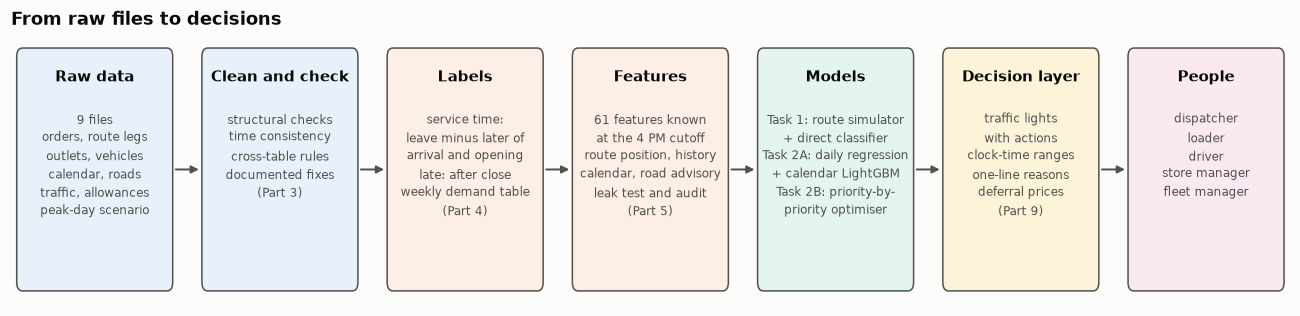

In [2]:
def box(ax, x, y, w, h, title, lines, color):
    ax.add_patch(FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.02,rounding_size=0.08",
                                facecolor=color, edgecolor=INK_SOFT, linewidth=1))
    ax.text(x + w / 2, y + h - 0.18, title, ha="center", va="top", fontsize=10, fontweight="bold", color=INK)
    ax.text(x + w / 2, y + h - 0.55, "\n".join(lines), ha="center", va="top", fontsize=8, color=INK_SOFT, linespacing=1.5)

def arrow(ax, x0, y0, x1, y1):
    ax.annotate("", xy=(x1, y1), xytext=(x0, y0), arrowprops=dict(arrowstyle="-|>", color=INK_SOFT, lw=1.3))

def flow(columns, height=2.2, figsize=(15, 3.2), title=None, loop=None):
    fig, ax = plt.subplots(figsize=figsize)
    w, gap = 2.15, 0.45
    for i, (head, items, color) in enumerate(columns):
        x = i * (w + gap)
        box(ax, x, 0, w, height, head, items, color)
        if i:
            arrow(ax, x - gap + 0.02, height / 2, x - 0.02, height / 2)
    bottom = -0.15
    if loop:
        # A feedback arrow under the boxes, from one column back to an earlier one
        src, dst, label = loop
        xs, xd = src * (w + gap) + w / 2, dst * (w + gap) + w / 2
        ax.annotate("", xy=(xd, -0.05), xytext=(xs, -0.05),
                    arrowprops=dict(arrowstyle="-|>", color=INK_SOFT, lw=1.3, connectionstyle="bar,fraction=-0.06"))
        ax.text((xs + xd) / 2, -0.5, label, ha="center", va="center", fontsize=8.5, color=INK_SOFT)
        bottom = -0.75
    ax.set_xlim(-0.1, len(columns) * (w + gap) - gap + 0.1)
    ax.set_ylim(bottom, height + 0.15)
    ax.axis("off")
    if title:
        ax.set_title(title, loc="left")
    return fig

LIGHT = ["#e8f0fb", "#fdeee6", "#e3f5ee", "#fdf3d9", "#fbe9f1", "#e6f2e6"]
pipeline = flow([
    ("Raw data", ["9 files", "orders, route legs", "outlets, vehicles", "calendar, roads", "traffic, allowances", "peak-day scenario"], LIGHT[0]),
    ("Clean and check", ["structural checks", "time consistency", "cross-table rules", "documented fixes", "(Part 3)"], LIGHT[0]),
    ("Labels", ["service time:", "leave minus later of", "arrival and opening", "late: after close", "weekly demand table", "(Part 4)"], LIGHT[1]),
    ("Features", ["61 features known", "at the 4 PM cutoff", "route position, history", "calendar, road advisory", "leak test and audit", "(Part 5)"], LIGHT[1]),
    ("Models", ["Task 1: route simulator", "+ direct classifier", "Task 2A: daily regression", "+ calendar LightGBM", "Task 2B: priority-by-", "priority optimiser"], LIGHT[2]),
    ("Decision layer", ["traffic lights", "with actions", "clock-time ranges", "one-line reasons", "deferral prices", "(Part 9)"], LIGHT[3]),
    ("People", ["dispatcher", "loader", "driver", "store manager", "fleet manager"], LIGHT[4]),
], title="From raw files to decisions")
(REPO_ROOT / "docs" / "figures").mkdir(parents=True, exist_ok=True)
pipeline.savefig(REPO_ROOT / "docs" / "figures" / "architecture_pipeline.png", dpi=160, bbox_inches="tight")
plt.show()